# Visualize YOLO bounding boxes on image

`cluster_test` 폴더 안의 이미지와 동일한 이름의 `.txt` 라벨 파일을 읽어, YOLO 포맷(class_id, x_center, y_center, width, height — 모두 0~1 정규화)의 바운딩 박스를 이미지 위에 그려줍니다.

라벨 파일의 각 줄은 `<번호>\t<class_id> <x_center> <y_center> <width> <height>` 형태이며, 맨 앞의 `<번호>`는 단순 인덱스이므로 무시합니다.

In [36]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# 대상 이미지/라벨 (확장자만 다른 동일한 파일명)
STEM = "rummikub_20260724_091948_2df578b4"
IMAGE_PATH = Path(STEM + ".jpg")
LABEL_PATH = Path(STEM + ".txt")

# data.yaml 의 names 리스트 (class_id -> 타일 이름)
CLASS_NAMES = ['Black1', 'Black10', 'Black11', 'Black12', 'Black13', 'Black2', 'Black3', 'Black4',
               'Black5', 'Black6', 'Black7', 'Black8', 'Black9', 'Blue1', 'Blue10', 'Blue11',
               'Blue12', 'Blue13', 'Blue2', 'Blue3', 'Blue4', 'Blue5', 'Blue6', 'Blue7', 'Blue8',
               'Blue9', 'Joker', 'Orange1', 'Orange10', 'Orange11', 'Orange12', 'Orange13',
               'Orange2', 'Orange3', 'Orange4', 'Orange5', 'Orange6', 'Orange7', 'Orange8',
               'Orange9', 'Red1', 'Red10', 'Red11', 'Red12', 'Red13', 'Red2', 'Red3', 'Red4',
               'Red5', 'Red6', 'Red7', 'Red8', 'Red9']

In [37]:
def parse_label_file(path: Path):
    """'<idx>\\t<class_id> <xc> <yc> <w> <h>' 형태의 라인들을 파싱한다."""
    boxes = []
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        # 앞쪽 인덱스 컬럼(탭 구분) 제거
        rest = line.split("\t", 1)[-1].strip()
        parts = rest.split()
        if len(parts) < 5:
            continue
        class_id = int(parts[0])
        xc, yc, w, h = map(float, parts[1:5])
        boxes.append((class_id, xc, yc, w, h))
    return boxes

boxes = parse_label_file(LABEL_PATH)
print(f"{len(boxes)}개 박스 로드됨")
boxes[:5]

20개 박스 로드됨


[(44, 0.201133, 0.805325, 0.132751, 0.054865),
 (4, 0.824386, 0.526306, 0.131678, 0.050037),
 (1, 0.614493, 0.137165, 0.126021, 0.046964),
 (52, 0.276604, 0.503887, 0.135726, 0.052515),
 (8, 0.272498, 0.358252, 0.130979, 0.043448)]

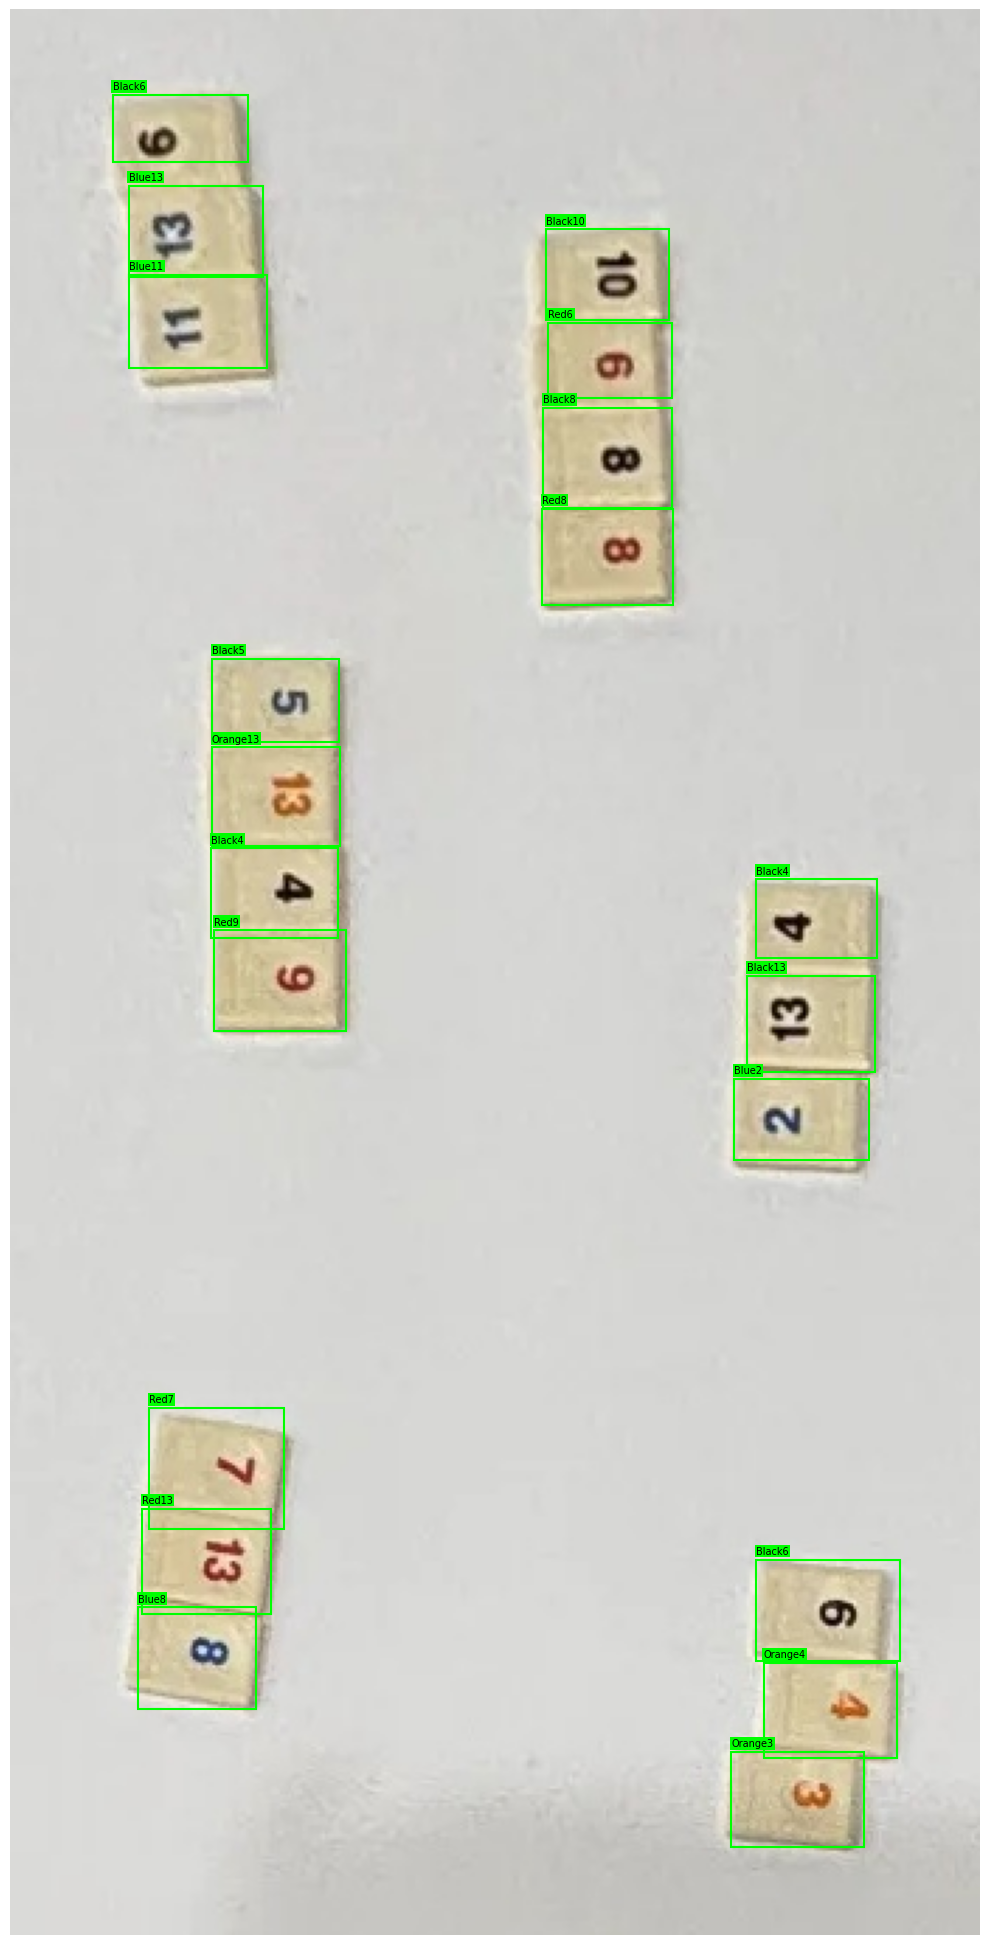

In [38]:
image = Image.open(IMAGE_PATH)
img_w, img_h = image.size

fig, ax = plt.subplots(1, figsize=(10, 10 * img_h / img_w))
ax.imshow(image)

for class_id, xc, yc, w, h in boxes:
    box_w = w * img_w
    box_h = h * img_h
    x0 = xc * img_w - box_w / 2
    y0 = yc * img_h - box_h / 2

    rect = patches.Rectangle((x0, y0), box_w, box_h,
                              linewidth=1.5, edgecolor="lime", facecolor="none")
    ax.add_patch(rect)

    label = CLASS_NAMES[class_id] if 0 <= class_id < len(CLASS_NAMES) else str(class_id)
    ax.text(x0, y0 - 2, label, color="black", fontsize=7,
            bbox=dict(facecolor="lime", edgecolor="none", pad=1))

ax.set_axis_off()
plt.tight_layout()
plt.show()

## 같은 세트(멜드)끼리 클러스터링

럼미큐브 테이블 위 타일들은 같은 세트(런/그룹)끼리는 서로 맞닿듯 가까이 놓이고, 세트와 세트 사이에는 상대적으로 큰 간격이 생긴다. 이 성질을 이용해 바운딩 박스 중심 좌표만으로 "같은 세트" 여부를 공간적으로 클러스터링한다.

- 라벨이 없는 비지도 클러스터링이고, 세트 개수를 미리 알 수 없으며, 세트 모양이 원형이 아닌 임의의 선형 배치이므로 `KMeans`보다 **DBSCAN**이 적합하다.
- `eps`(같은 클러스터로 볼 최대 거리)는 이미지/타일 크기에 따라 달라지므로, 타일 간 최근접 거리의 중앙값에 여유 배수를 곱해 자동으로 계산한다 (하드코딩 금지).

In [39]:
# ------------------------------------------------------------------
# 필요 라이브러리 설치 (최초 1회, rummikub-yolo 가상환경 기준)
#
#   pip install scikit-learn
#
# scikit-learn 설치 시 아래 의존 패키지가 함께 설치된다:
#   - scipy           (ConvexHull로 세트 외곽선을 그리는 데 사용)
#   - joblib, threadpoolctl
#
# 용도:
#   - sklearn.cluster.DBSCAN : 타일 좌표를 거리 기반으로 클러스터링해 같은 세트로 묶음
#   - scipy.spatial.ConvexHull : 세트별 타일들을 감싸는 외곽선을 그려 시각화
# (numpy, matplotlib, Pillow는 바운딩 박스 시각화 셀에서 이미 사용 중이므로 추가 설치 불필요)
# ------------------------------------------------------------------

import numpy as np
from sklearn.cluster import DBSCAN
from scipy.spatial import ConvexHull

In [40]:
# 박스 중심을 픽셀 좌표로 변환
centers_px = np.array([[xc * img_w, yc * img_h] for _, xc, yc, w, h in boxes])

# eps 자동 결정: 각 타일의 최근접 이웃 거리(같은 세트 안 타일 간 거리)의 중앙값에
# 여유 배수를 곱한다. 같은 세트 내 간격은 이 값보다 훨씬 작고, 세트 간 간격은
# 이 값보다 훨씬 크므로 두 경우를 잘 분리해준다.
n = len(centers_px)
nearest_dists = []
for i in range(n):
    d = np.linalg.norm(centers_px - centers_px[i], axis=1)
    d[i] = np.inf
    nearest_dists.append(d.min())

eps = np.median(nearest_dists) * 1.5
print(f"자동 계산된 eps: {eps:.1f}px (최근접 거리 중앙값 {np.median(nearest_dists):.1f}px 기준)")

# min_samples=1: 세트에 타일이 1개만 검출된 경우도 하나의 클러스터로 인정 (노이즈로 버리지 않음)
dbscan = DBSCAN(eps=eps, min_samples=1)
cluster_labels = dbscan.fit_predict(centers_px)

n_clusters = len(set(cluster_labels))
print(f"{n_clusters}개의 세트로 클러스터링됨")

for c in sorted(set(cluster_labels)):
    tile_names = [CLASS_NAMES[boxes[i][0]] for i in range(n) if cluster_labels[i] == c]
    print(f"세트 {c}: {tile_names}")

자동 계산된 eps: 50.9px (최근접 거리 중앙값 33.9px 기준)
6개의 세트로 클러스터링됨
세트 0: ['Red13', 'Blue8', 'Red7']
세트 1: ['Black13', 'Blue2', 'Black4']
세트 2: ['Black10', 'Red8', 'Black8', 'Red6']
세트 3: ['Red9', 'Black5', 'Orange13', 'Black4']
세트 4: ['Orange4', 'Orange3', 'Black6']
세트 5: ['Blue13', 'Blue11', 'Black6']


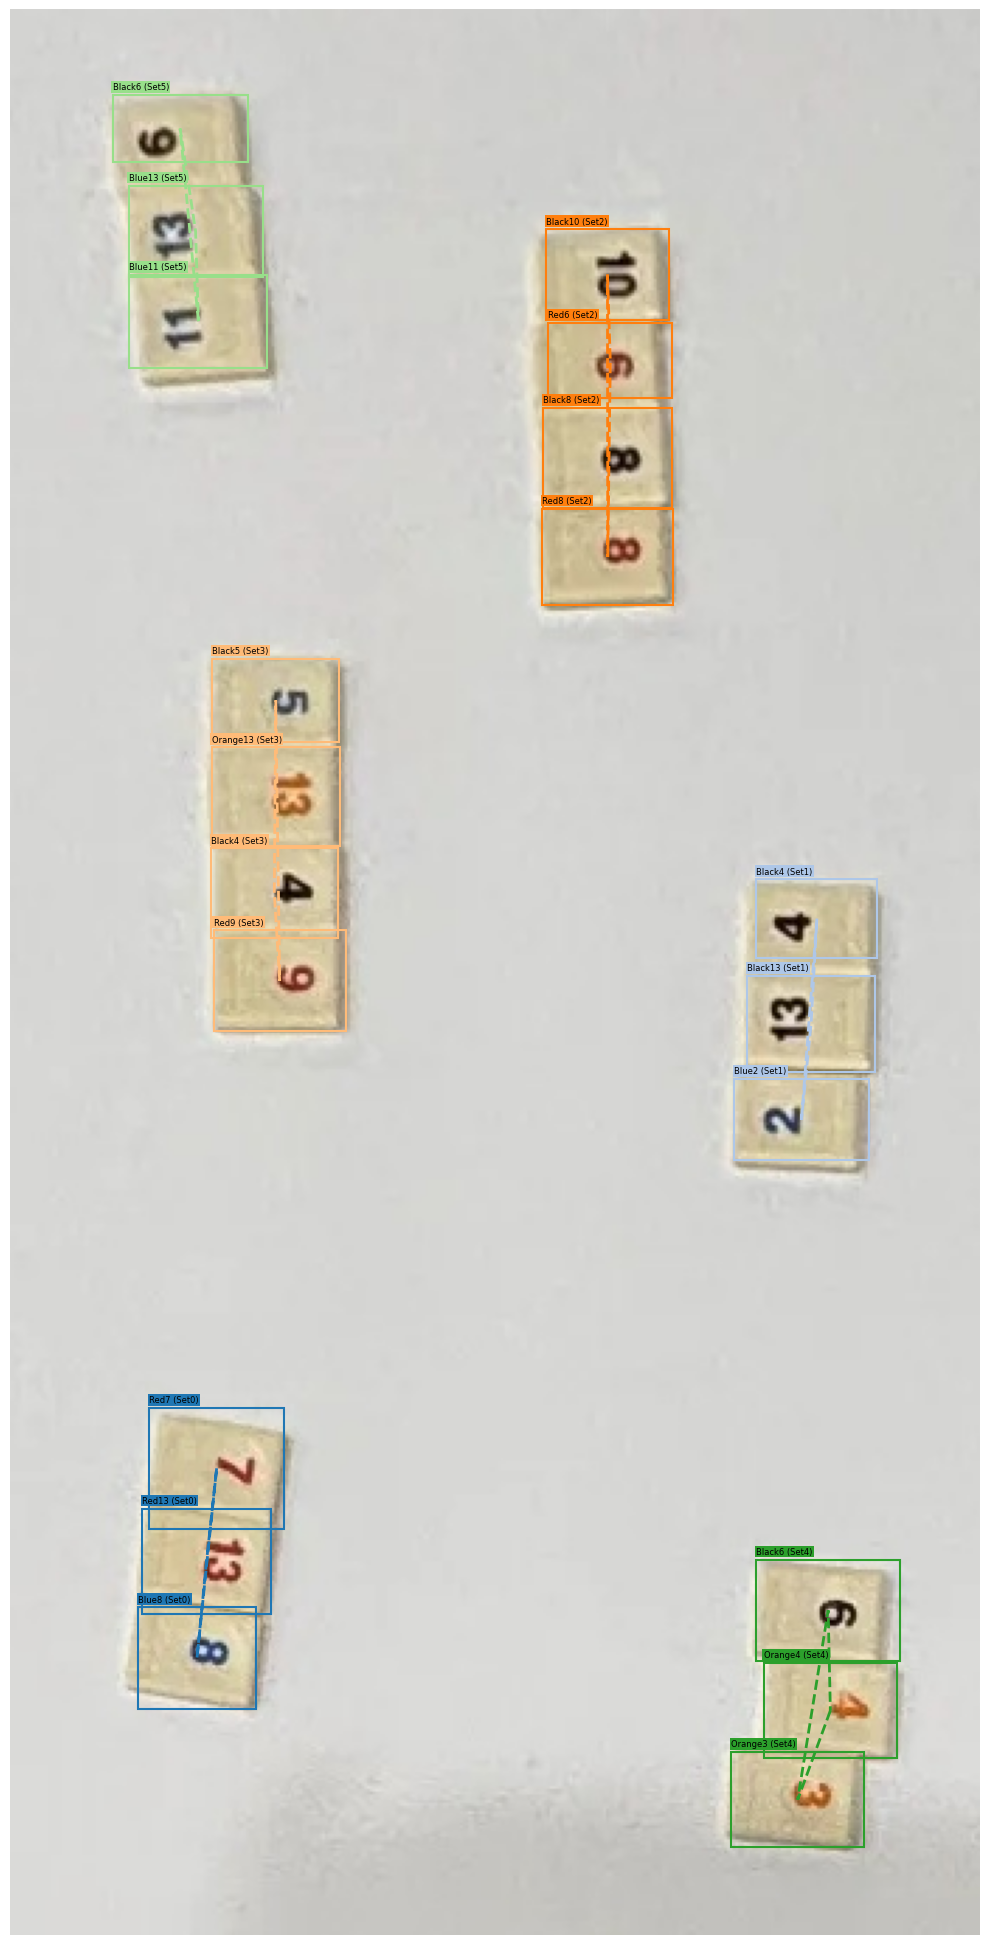

In [41]:
# 클러스터(세트)별로 바운딩 박스 색을 다르게 칠하고, 3개 이상인 세트는 외곽선(ConvexHull)도 그린다
cmap = plt.get_cmap("tab20")
colors = {c: cmap(i % 20) for i, c in enumerate(sorted(set(cluster_labels)))}

fig, ax = plt.subplots(1, figsize=(10, 10 * img_h / img_w))
ax.imshow(image)

for i, (class_id, xc, yc, w, h) in enumerate(boxes):
    color = colors[cluster_labels[i]]
    box_w, box_h = w * img_w, h * img_h
    x0, y0 = xc * img_w - box_w / 2, yc * img_h - box_h / 2

    rect = patches.Rectangle((x0, y0), box_w, box_h,
                              linewidth=1.5, edgecolor=color, facecolor="none")
    ax.add_patch(rect)

    # matplotlib 기본 폰트(DejaVu Sans)는 한글 글리프가 없으므로 라벨은 영문으로 표기
    label = f"{CLASS_NAMES[class_id]} (Set{cluster_labels[i]})"
    ax.text(x0, y0 - 2, label, color="black", fontsize=6,
            bbox=dict(facecolor=color, edgecolor="none", pad=1))

# 세트별 외곽선: 점이 3개 이상 있어야 ConvexHull을 계산할 수 있음
for c in sorted(set(cluster_labels)):
    pts = centers_px[cluster_labels == c]
    color = colors[c]
    if len(pts) >= 3:
        hull = ConvexHull(pts)
        hull_pts = pts[hull.vertices]
        polygon = patches.Polygon(hull_pts, closed=True, fill=False,
                                   edgecolor=color, linewidth=2, linestyle="--")
        ax.add_patch(polygon)
    elif len(pts) == 2:
        ax.plot(pts[:, 0], pts[:, 1], linestyle="--", linewidth=2, color=color)

ax.set_axis_off()
plt.tight_layout()
plt.show()

## HSV / Lab을 이용한 숫자 영역 강조

각 타일 바운딩 박스를 크롭해서, 타일 배경(크림색)과 인쇄된 숫자(검정/파랑/빨강/주황)를 색공간 정보로 분리한다.

- **Lab (L채널) 적응형 임계값**: 숫자 색이 4가지(검정·파랑·빨강·주황)로 제각각이라 고정 색 범위로는 못 잡지만, 어떤 색이든 배경보다 명도(L)가 확실히 낮다는 점은 공통이다. `cv2.adaptiveThreshold`로 크롭 내 지역 평균 명도 대비 어두운 픽셀을 찾으면, 촬영 시 생기는 그림자/조명 불균일에도 전역 임계값보다 강건하다.
- **HSV (S, V채널)**: 하이라이트(반사광)는 Lab 기준으로 배경과 차이가 나서 오탐될 수 있는데, 채도(S)가 매우 낮고 명도(V)가 매우 높은 픽셀(흰색에 가까운 반사광)을 별도로 걸러내는 데 사용한다.
- 위 두 마스크를 합친 뒤 연결 성분(connected component)을 구하고, 중심에 가장 가까운 성분을 "본체"로 선택한다.
- **2자리 숫자 처리**: "13", "10"처럼 숫자가 2자리면 각 자릿수가 서로 떨어져 있어 별도의 연결 성분으로 분리된다. 본체와 (1) 충분히 가깝고 (2) 한 축으로 정렬되어 있고 (3) 크기도 본체와 비슷한 성분만 추가로 병합해서 두 자릿수를 모두 잡아내되, 세 조건을 동시에 요구해 우연히 가까운 배경 얼룩·테두리 잡음까지 병합되지 않도록 임계값을 보수적으로 잡았다.

In [42]:
# opencv-python은 requirements.txt에 이미 포함되어 있어 추가 설치 불필요 (cv2.cvtColor로 HSV/Lab 변환)
import cv2

image_np = np.array(image.convert("RGB"))


def crop_tile(xc, yc, w, h, pad=0.15):
    """타일 바운딩 박스를 pad 비율만큼 안쪽으로 당겨 크롭한다.
    (타일 테두리 음영을 배경으로 오인하지 않도록 살짝 여유를 둔다)"""
    box_w, box_h = w * img_w, h * img_h
    cx, cy = xc * img_w, yc * img_h
    x0 = int(max(0, cx - box_w / 2 * (1 - pad)))
    x1 = int(min(img_w, cx + box_w / 2 * (1 - pad)))
    y0 = int(max(0, cy - box_h / 2 * (1 - pad)))
    y1 = int(min(img_h, cy + box_h / 2 * (1 - pad)))
    return image_np[y0:y1, x0:x1], (x0, y0)


def _bbox_gap(b1, b2):
    """두 (x0,y0,w,h) bbox 사이의 최소 거리 (겹치면 0)"""
    ax0, ay0, aw, ah = b1
    bx0, by0, bw, bh = b2
    ax1, ay1, bx1, by1 = ax0 + aw, ay0 + ah, bx0 + bw, by0 + bh
    dx = max(ax0 - bx1, bx0 - ax1, 0)
    dy = max(ay0 - by1, by0 - ay1, 0)
    return (dx ** 2 + dy ** 2) ** 0.5


def _axis_overlap_ratio(b1, b2):
    """두 bbox가 가로 또는 세로 축 중 하나로 얼마나 겹치는지 (같은 숫자의 자릿수는 한 축으로 정렬됨)"""
    ax0, ay0, aw, ah = b1
    bx0, by0, bw, bh = b2
    ax1, ay1, bx1, by1 = ax0 + aw, ay0 + ah, bx0 + bw, by0 + bh
    x_overlap = max(0, min(ax1, bx1) - max(ax0, bx0))
    y_overlap = max(0, min(ay1, by1) - max(ay0, by0))
    return max(x_overlap / max(1, min(aw, bw)), y_overlap / max(1, min(ah, bh)))


def digit_mask(crop_rgb):
    """크롭 안에서 숫자 픽셀만 True인 불리언 마스크를 반환한다.
    2자리 숫자는 자릿수끼리 떨어져 있어 별도 연결 성분이 되므로, 본체와 가깝고
    정렬되어 있고 크기가 비슷한 성분까지 함께 병합한다."""
    lab_l = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2LAB)[:, :, 0]
    h, w = lab_l.shape[:2]
    block_size = max(5, (min(h, w) // 2) | 1)  # 홀수, 크롭 크기에 비례한 지역 창
    raw_mask = cv2.adaptiveThreshold(
        lab_l, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, block_size, 5
    )

    hsv = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2HSV)
    sat, val = hsv[:, :, 1].astype(np.float32), hsv[:, :, 2].astype(np.float32)
    glare = (val > 245) & (sat < 25)  # 채도 낮고 매우 밝은 반사광 픽셀
    raw_mask[glare] = 0
    raw_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))

    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(raw_mask, connectivity=8)
    if n_labels <= 1:
        return np.zeros_like(raw_mask, dtype=bool)

    center = np.array([w / 2, h / 2])
    candidates = []  # (label, area, bbox, score, touches_border)
    for lbl in range(1, n_labels):
        area = stats[lbl, cv2.CC_STAT_AREA]
        if area < 4:
            continue
        x0, y0, cw, ch = stats[lbl, cv2.CC_STAT_LEFT], stats[lbl, cv2.CC_STAT_TOP], \
                          stats[lbl, cv2.CC_STAT_WIDTH], stats[lbl, cv2.CC_STAT_HEIGHT]
        touches_border = x0 <= 0 or y0 <= 0 or x0 + cw >= w or y0 + ch >= h
        dist = np.linalg.norm(centroids[lbl] - center)
        score = area / (1 + dist)
        if touches_border:
            score *= 0.15  # 크롭 테두리에 닿는 성분(잔여 배경/음영)은 감점
        candidates.append((lbl, area, (x0, y0, cw, ch), score, touches_border))

    if not candidates:
        return np.zeros_like(raw_mask, dtype=bool)

    # 본체(가장 중심에 가깝고 큰 성분) 선택
    seed_lbl, seed_area, seed_bbox, _, _ = max(candidates, key=lambda c: c[3])

    # 본체와 같은 숫자의 다른 자릿수로 볼 수 있는 성분만 추가로 병합
    gap_thresh = 0.15 * min(h, w)
    keep_labels = {seed_lbl}
    for lbl, area, bbox, score, touches_border in candidates:
        if lbl == seed_lbl or touches_border:
            continue
        if area < 0.45 * seed_area:  # 본체 대비 너무 작으면 잡음으로 간주
            continue
        if _bbox_gap(seed_bbox, bbox) > gap_thresh:  # 너무 멀면 다른 자릿수가 아님
            continue
        if _axis_overlap_ratio(seed_bbox, bbox) < 0.3:  # 가로/세로 어느 축으로도 안 맞으면 제외
            continue
        keep_labels.add(lbl)

    return raw_mask.astype(bool) & np.isin(labels, list(keep_labels))

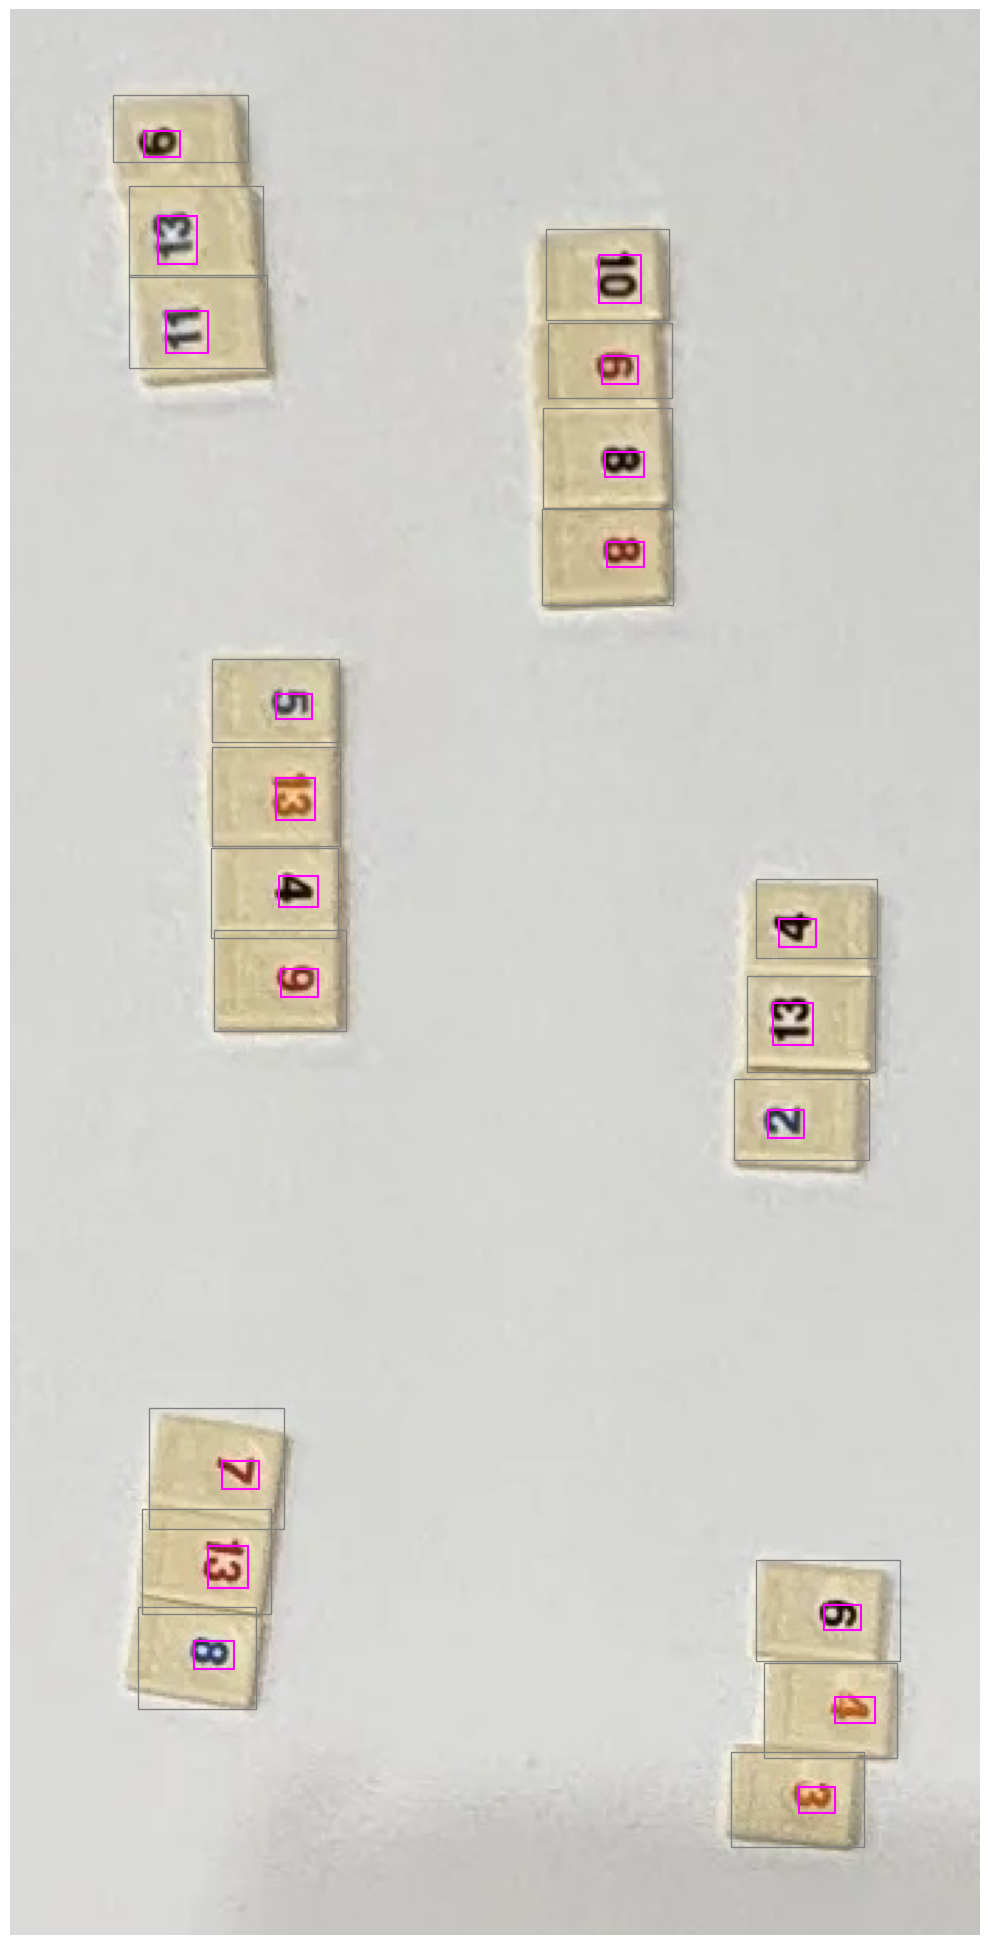

In [43]:
# 원본 이미지 위에 타일 박스(회색 얇은 선)와 숫자 영역(마젠타)을 함께 표시
fig, ax = plt.subplots(1, figsize=(10, 10 * img_h / img_w))
ax.imshow(image)

for class_id, xc, yc, w, h in boxes:
    box_w, box_h = w * img_w, h * img_h
    x0, y0 = xc * img_w - box_w / 2, yc * img_h - box_h / 2
    ax.add_patch(patches.Rectangle((x0, y0), box_w, box_h,
                                    linewidth=1, edgecolor="gray", facecolor="none"))

    crop, (ox, oy) = crop_tile(xc, yc, w, h)
    mask = digit_mask(crop)
    ys, xs = np.where(mask)
    if len(xs) == 0:
        continue
    # 크롭 기준 숫자 바운딩 박스를 원본 이미지 좌표로 변환
    dx0, dy0, dx1, dy1 = ox + xs.min(), oy + ys.min(), ox + xs.max() + 1, oy + ys.max() + 1
    ax.add_patch(patches.Rectangle((dx0, dy0), dx1 - dx0, dy1 - dy0,
                                    linewidth=1.5, edgecolor="magenta", facecolor="none"))

ax.set_axis_off()
plt.tight_layout()
plt.show()

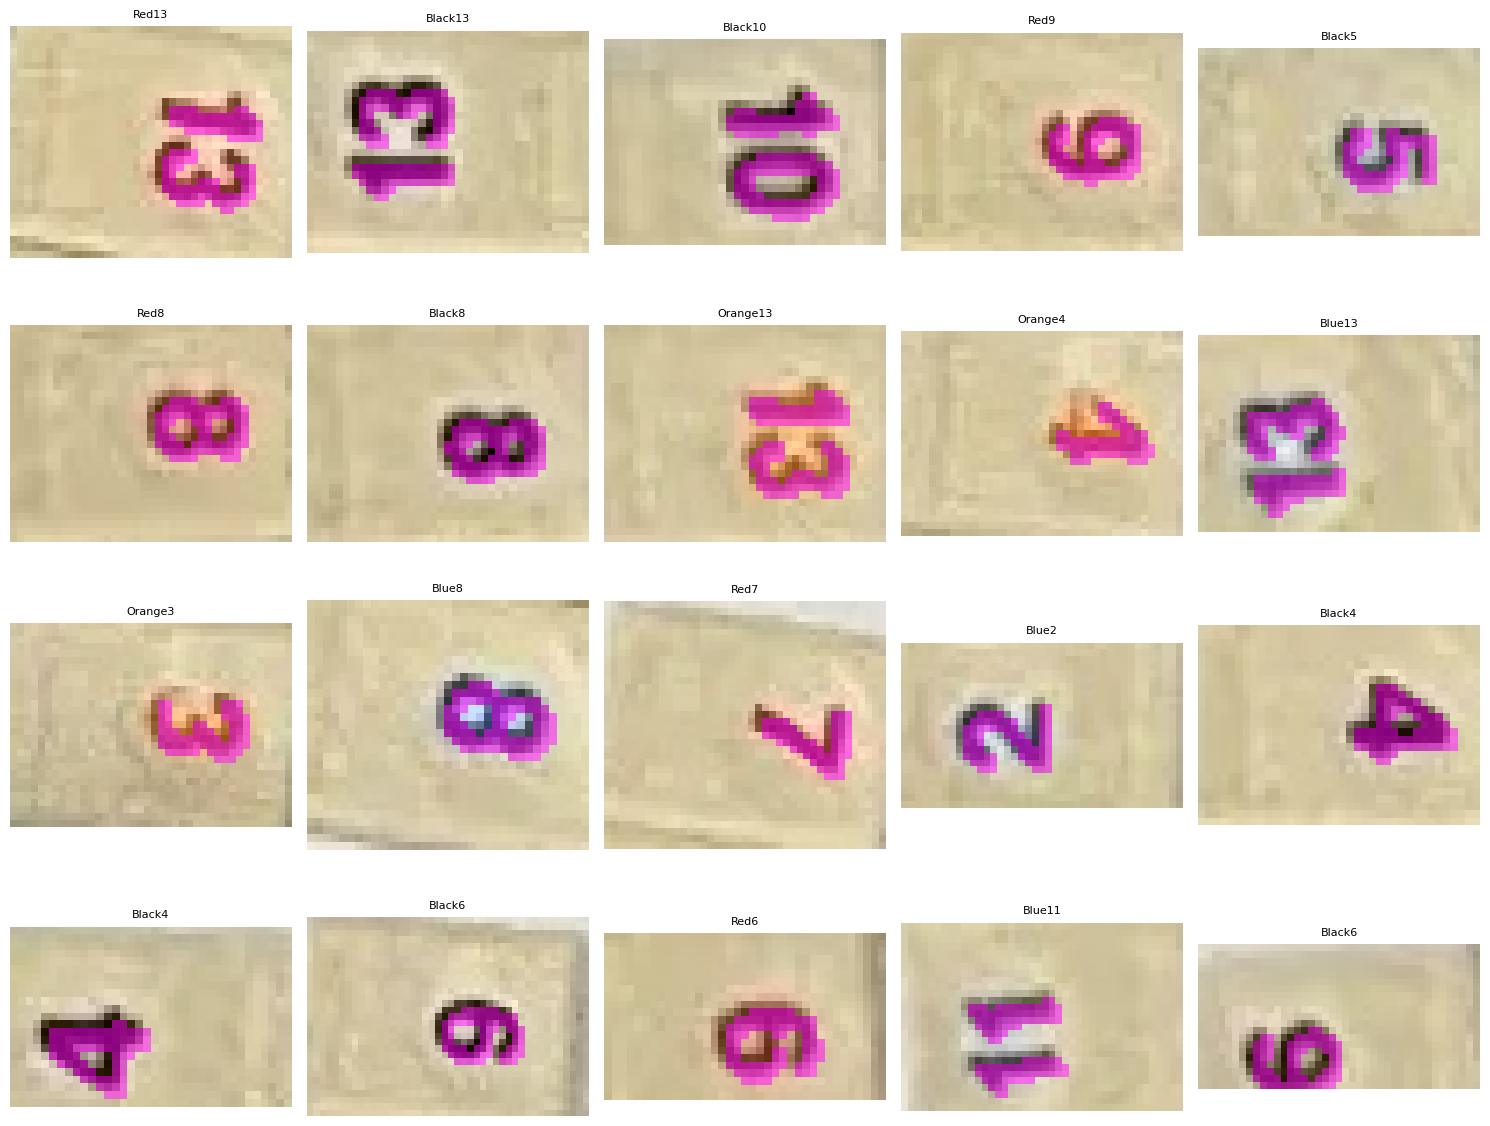

In [44]:
# 타일별 크롭 + 숫자 마스크를 그리드로 확대해서 자세히 검증
n = len(boxes)
n_cols = 5
n_rows = -(-n // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

for ax, (class_id, xc, yc, w, h) in zip(axes.flat, boxes):
    crop, _ = crop_tile(xc, yc, w, h)
    mask = digit_mask(crop)
    overlay = crop.copy()
    overlay[mask] = [255, 0, 255]
    blend = cv2.addWeighted(crop, 0.5, overlay, 0.5, 0)
    ax.imshow(blend)
    ax.set_title(CLASS_NAMES[class_id], fontsize=8)
    ax.axis("off")

for ax in axes.flat[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 배경 제거 후 숫자만 표시

`digit_mask`가 이미 숫자/배경을 픽셀 단위로 분리해두었으므로, 마스크가 아닌(배경) 픽셀을 흰색으로 덮어써서 숫자만 남긴다. 원본 이미지 전체에 대해 한 번, 그리고 타일별 크롭 단위로 한 번 보여준다.

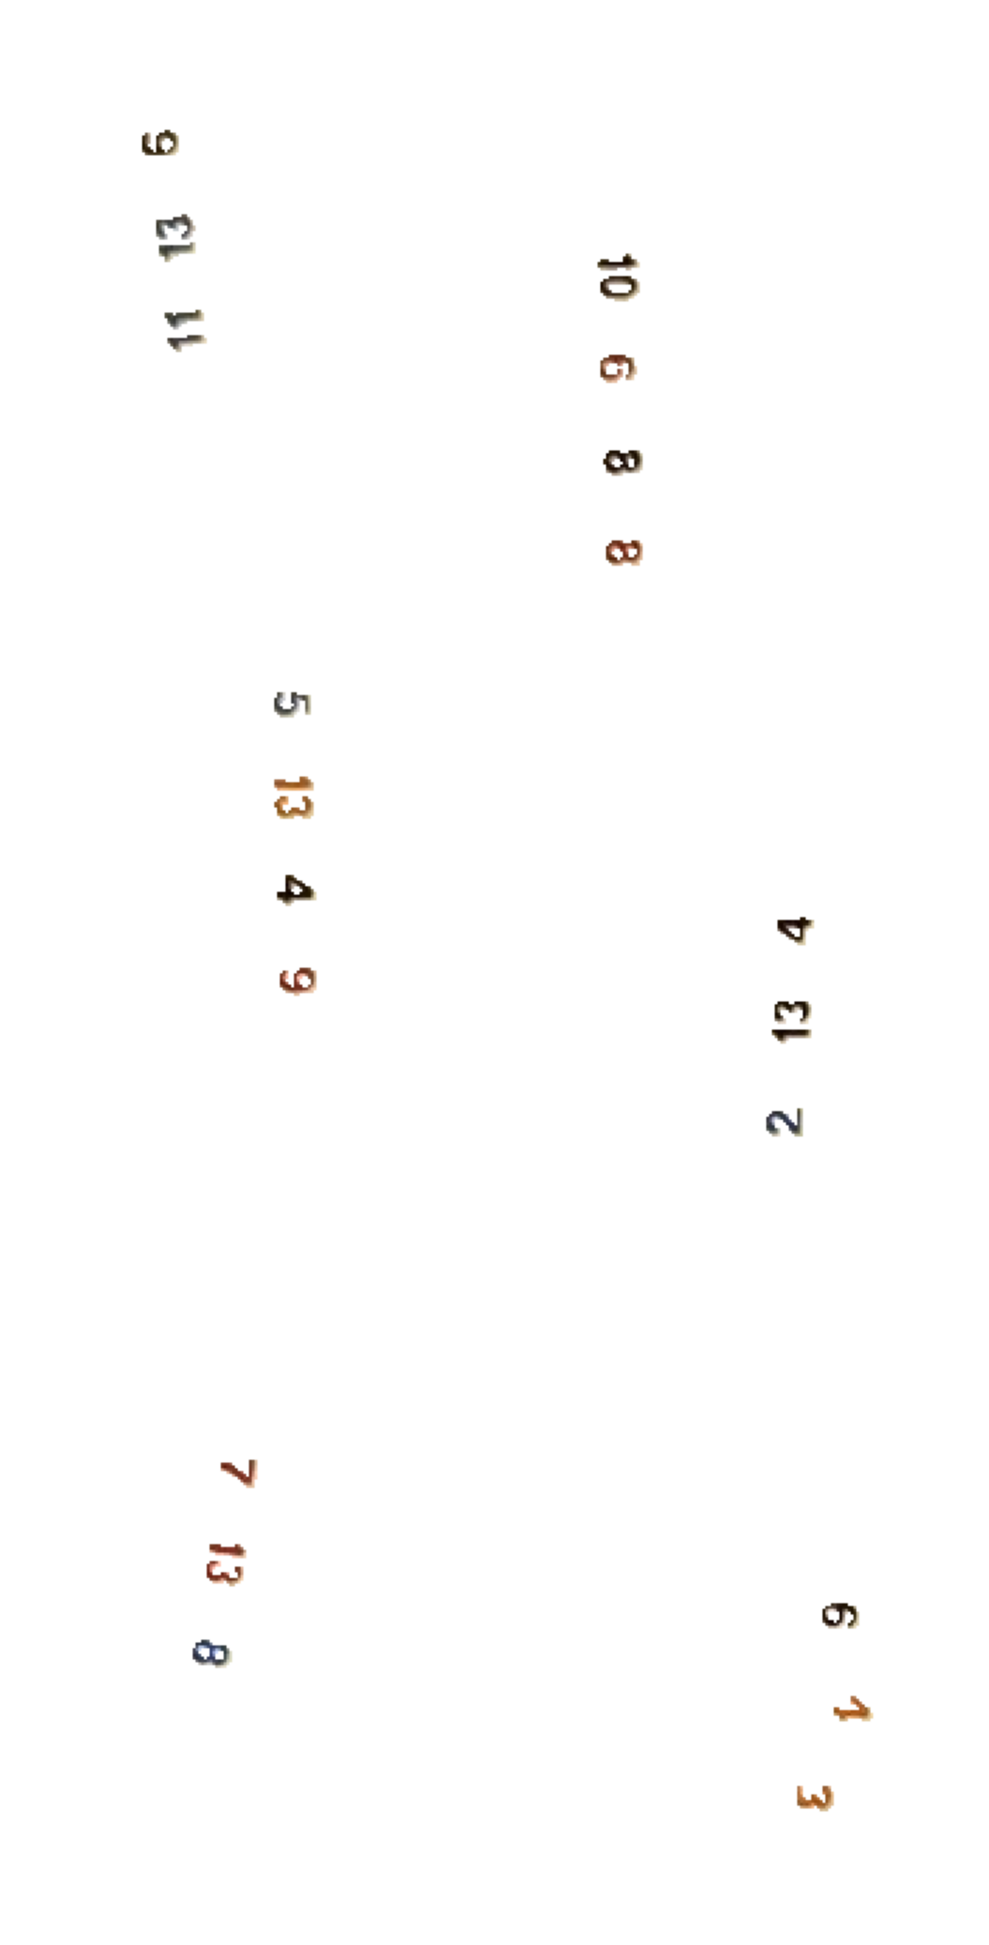

In [45]:
# 원본 이미지 전체를 흰 배경으로 지우고, 숫자 픽셀만 원래 위치/색으로 남긴다
digits_only = np.full_like(image_np, 255)

for class_id, xc, yc, w, h in boxes:
    crop, (ox, oy) = crop_tile(xc, yc, w, h)
    mask = digit_mask(crop)
    ch, cw = mask.shape
    region = digits_only[oy:oy + ch, ox:ox + cw]
    region[mask] = crop[mask]

fig, ax = plt.subplots(1, figsize=(10, 10 * img_h / img_w))
ax.imshow(digits_only)
ax.set_axis_off()
plt.tight_layout()
plt.show()

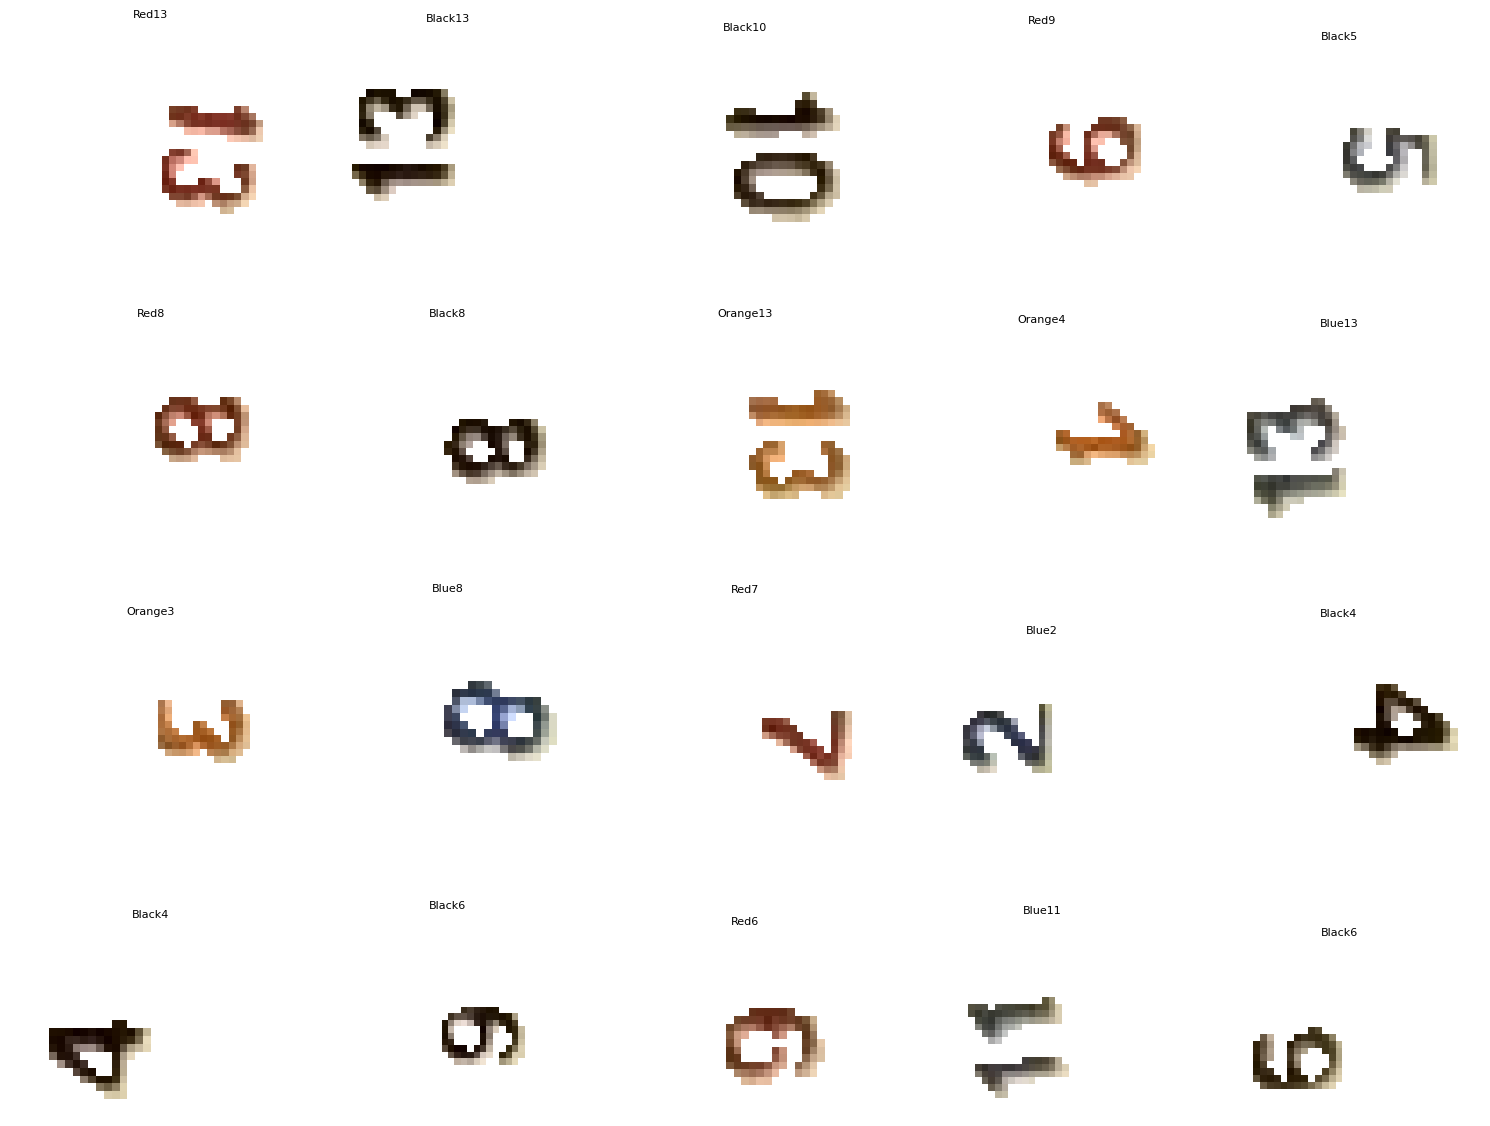

In [46]:
# 타일별로도 동일하게 배경을 지우고 숫자만 남긴 크롭을 그리드로 확인
n = len(boxes)
n_cols = 5
n_rows = -(-n // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

for ax, (class_id, xc, yc, w, h) in zip(axes.flat, boxes):
    crop, _ = crop_tile(xc, yc, w, h)
    mask = digit_mask(crop)
    cutout = np.full_like(crop, 255)
    cutout[mask] = crop[mask]
    ax.imshow(cutout)
    ax.set_title(CLASS_NAMES[class_id], fontsize=8)
    ax.axis("off")

for ax in axes.flat[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()